# Logistic Regression - Diabetes Risk

## 1. Imports

In [1]:
# Importing essential libraries for data manipulation, visualization, and machine learning evaluation
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)
RANDOM_STATE = 42

## 2. Load data
Upload files: `undersampled_features.csv`, `undersampled_target.csv` (training) and `preprocessed_xtest.csv`, `ytest.csv` (test).

In [2]:
# Prompting to upload the necessary CSV files into the Google Colab environment
from google.colab import files
uploaded = files.upload()

Saving undersampled_features.csv to undersampled_features.csv
Saving preprocessed_xtest.csv to preprocessed_xtest.csv
Saving undersampled_target.csv to undersampled_target.csv
Saving ytest.csv to ytest.csv


In [3]:
# Loading training and testing datasets, verifying their dimensions, and printing basic statistics

X_train = pd.read_csv("undersampled_features.csv")
y_train = pd.read_csv("undersampled_target.csv")["Diabetes_binary"].astype(int)
X_test  = pd.read_csv("preprocessed_xtest.csv")
y_test  = pd.read_csv("ytest.csv")["Diabetes_binary"].astype(int)

assert len(X_train) == len(y_train) and len(X_test) == len(y_test)
assert list(X_train.columns) == list(X_test.columns)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train class balance:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test class balance: ", y_test.value_counts(normalize=True).round(3).to_dict())
print("Missing values:", int(X_train.isna().sum().sum() + X_test.isna().sum().sum()))

Train: (56554, 28) | Test: (50736, 28)
Train class balance: {0: 0.5, 1: 0.5}
Test class balance:  {0: 0.861, 1: 0.139}
Missing values: 0


## 3. Remove redundant dummy columns
Each binary feature is stored as both `_0.0` and `_1.0` (perfectly collinear). Keep only `_1.0`, and drop `Education_1.0` as the reference level.

In [4]:
# Removing perfectly collinear dummy variables to avoid the 'dummy variable trap' in Logistic Regression
drop_cols = [c for c in X_train.columns if c.endswith("_0.0")] + ["Education_1.0"]
drop_cols = [c for c in drop_cols if c in X_train.columns]
X_train = X_train.drop(columns=drop_cols); X_test = X_test.drop(columns=drop_cols)
print("Features used:", X_train.shape[1]); print(list(X_train.columns))

Features used: 19
['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Income', 'HighBP_1.0', 'HighChol_1.0', 'Smoker_1.0', 'Stroke_1.0', 'HeartDiseaseorAttack_1.0', 'PhysActivity_1.0', 'HvyAlcoholConsump_1.0', 'DiffWalk_1.0', 'Education_2.0', 'Education_3.0', 'Education_4.0', 'Education_5.0', 'Education_6.0']


## 4. Stratified 5-fold cross-validation (train & validate)
The training data is split into 5 stratified folds. The model is trained 5 times, each time on 4 folds and validated on the remaining fold. The test set is **not** used here.

In [5]:
# Setting up 5-fold cross-validation to evaluate model stability using only the training data
model = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=RANDOM_STATE)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy":"accuracy", "precision":"precision", "recall":"recall",
           "f1":"f1", "roc_auc":"roc_auc", "pr_auc":"average_precision"}

# cross_validate clones `model` for each fold: trains on 4 folds, validates on 1 fold, repeated 5 times
cv = cross_validate(model, X_train, y_train, cv=skf, scoring=scoring, n_jobs=-1)

cv_df = pd.DataFrame({m: cv[f"test_{m}"] for m in scoring}, index=[f"Fold {i}" for i in range(1, 6)])
cv_df.loc["Mean"] = cv_df.mean(); cv_df.loc["Std"] = cv_df.iloc[:5].std()
display(cv_df.round(4))

,accuracy,precision,recall,f1,roc_auc,pr_auc
Fold 1,0.7454,0.7380,0.7607,0.7492,0.8214,0.7920
Fold 2,0.7387,0.7314,0.7542,0.7426,0.8160,0.7900
Fold 3,0.7447,0.7342,0.7671,0.7503,0.8197,0.7898
Fold 4,0.7486,0.7418,0.7626,0.7520,0.8259,0.7988
Fold 5,0.7478,0.7388,0.7668,0.7525,0.8218,0.7944
Mean,0.7450,0.7369,0.7623,0.7493,0.8210,0.7930
Std,0.0039,0.0041,0.0053,0.0040,0.0036,0.0037


## 5. Train the final model
After cross-validation confirms the model is stable, fit it once on the **entire** training set.

In [6]:
# Training the final Logistic Regression model on the complete, entire training dataset
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## 6. Model evaluation (on the held-out test set)

In [7]:
# Predicting on the unseen test data and calculating key performance metrics (Accuracy, Precision, Recall, F1, AUC)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

def metrics(y_true, y_hat, y_p):
    return {"Accuracy":  accuracy_score(y_true, y_hat),
            "Precision": precision_score(y_true, y_hat),
            "Recall":    recall_score(y_true, y_hat),
            "F1":        f1_score(y_true, y_hat),
            "ROC-AUC":   roc_auc_score(y_true, y_p),
            "PR-AUC":    average_precision_score(y_true, y_p)}

res = pd.DataFrame({"Train": metrics(y_train, model.predict(X_train), model.predict_proba(X_train)[:,1]),
                    "Test (real distribution)":  metrics(y_test, y_pred, y_prob)}).round(4)
display(res)
print(f"Note: test set is imbalanced ({y_test.mean():.1%} positive) -> PR-AUC baseline = {y_test.mean():.3f}; focus on Recall, F1, ROC-AUC, PR-AUC, not Accuracy.")
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"], digits=4))

,Train,Test (real distribution)
Accuracy,0.7458,0.7309
Precision,0.7376,0.3101
Recall,0.7630,0.7605
F1,0.7501,0.4406
ROC-AUC,0.8212,0.8168
PR-AUC,0.7933,0.3891


Note: test set is imbalanced (13.9% positive) -> PR-AUC baseline = 0.139; focus on Recall, F1, ROC-AUC, PR-AUC, not Accuracy.
              precision    recall  f1-score   support

 No Diabetes     0.9493    0.7262    0.8229     43667
    Diabetes     0.3101    0.7605    0.4406      7069

    accuracy                         0.7309     50736
   macro avg     0.6297    0.7433    0.6317     50736
weighted avg     0.8603    0.7309    0.7696     50736



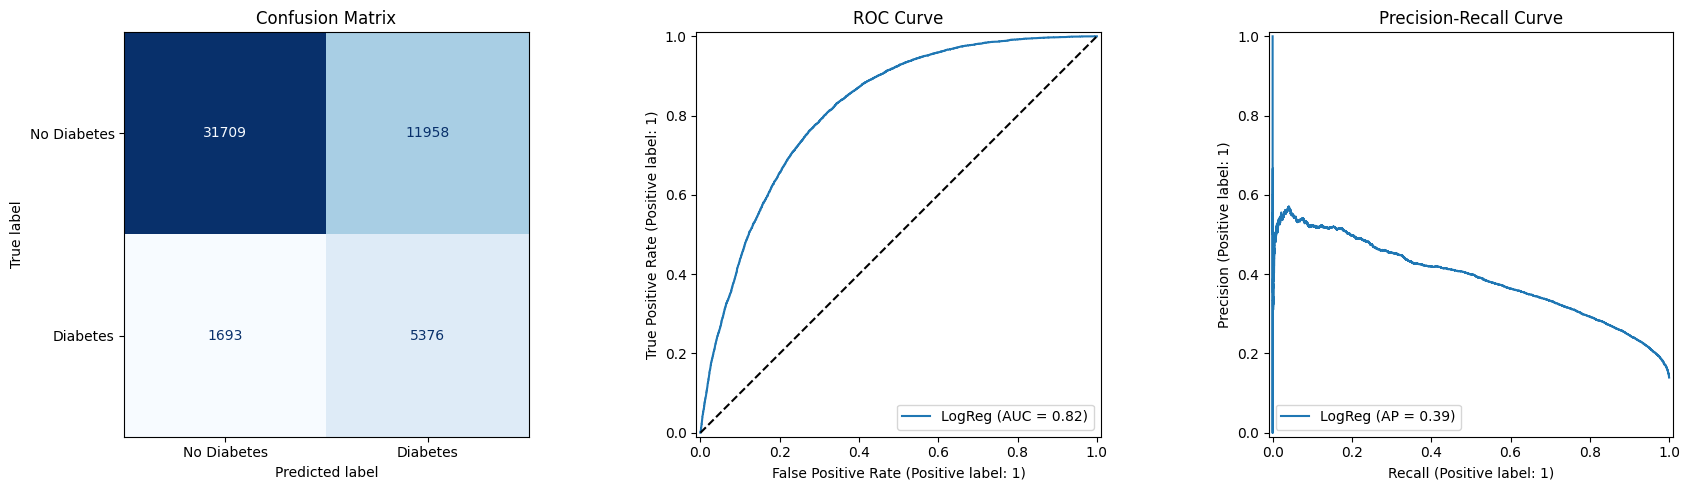

In [8]:
# Visualizing model performance using a Confusion Matrix, ROC Curve, and Precision-Recall Curve
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=["No Diabetes", "Diabetes"]).plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title("Confusion Matrix")
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax[1], name="LogReg"); ax[1].plot([0,1],[0,1],"k--")
ax[1].set_title("ROC Curve")
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax[2], name="LogReg")
ax[2].set_title("Precision-Recall Curve")
plt.tight_layout(); plt.show()

## 7. Feature importance (coefficients & odds ratios)

,Feature,Coefficient,Odds Ratio
0,HighBP_1.0,0.7638,2.1464
1,HvyAlcoholConsump_1.0,-0.7406,0.4768
2,GenHlth,0.6352,1.8873
3,HighChol_1.0,0.6001,1.8223
4,BMI,0.4903,1.6328
5,Age,0.4558,1.5774
6,HeartDiseaseorAttack_1.0,0.2993,1.3489
7,Education_6.0,-0.2903,0.7481
8,Stroke_1.0,0.2336,1.2631
9,Education_4.0,-0.2035,0.8159


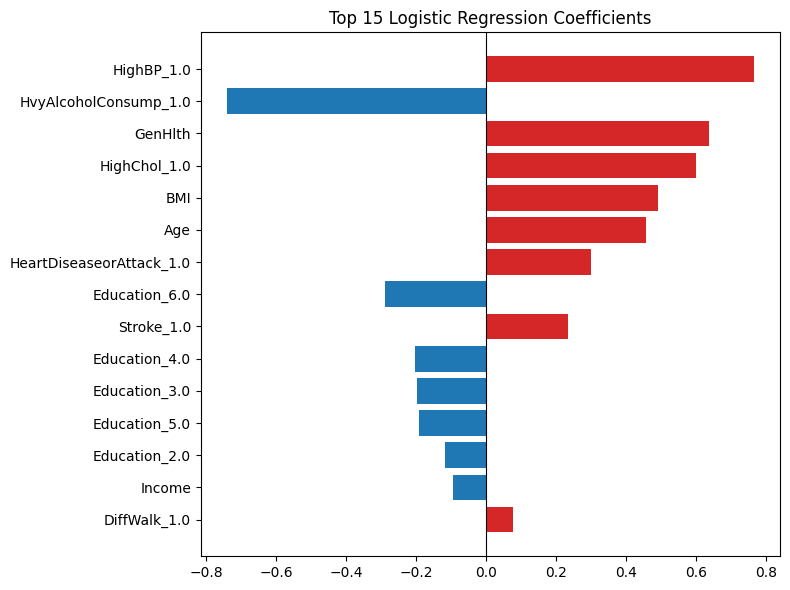

In [9]:
# Extracting model coefficients and odds ratios to identify which features impact the predictions the most
coef = pd.DataFrame({"Feature": X_train.columns, "Coefficient": model.coef_[0]})
coef["Odds Ratio"] = np.exp(coef["Coefficient"])
coef = coef.reindex(coef["Coefficient"].abs().sort_values(ascending=False).index).reset_index(drop=True)
display(coef.round(4))

top = coef.head(15).iloc[::-1]
plt.figure(figsize=(8, 6))
plt.barh(top["Feature"], top["Coefficient"], color=np.where(top["Coefficient"] > 0, "tab:red", "tab:blue"))
plt.axvline(0, color="k", lw=0.8); plt.title("Top 15 Logistic Regression Coefficients")
plt.tight_layout(); plt.show()

## 8. Save the model

In [10]:
# Saving the trained model to a file for future use or deployment
import joblib
joblib.dump(model, 'logreg.pt')
print('Model saved as logreg.pt')

Model saved as logreg.pt


In [11]:
# Downloading the saved model file directly from Google Colab to the local machine
from google.colab import files
files.download('logreg.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>